Task l
import libraries 
load data 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
Path("charts").mkdir(exist_ok=True)
df = pd.read_excel('Dataset for Data Analytics.xlsx')

Data exploration

In [4]:
df.shape

(1200, 14)

In [5]:
df.head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NaN,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [7]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Data Cleaaning 

In [10]:
df['OrderID'].duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(1200, 14)

In [13]:
df["CouponCode"] = df["CouponCode"].replace("nan", np.nan)
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

FEATURE ENGINEERING

In [23]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Month_Number'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

BASIC KPIs

In [17]:
if 'Revenue' not in df.columns:
    df['Revenue'] = df['TotalPrice']
total_revenue = df['Revenue'].sum()
total_revenue

np.float64(1264761.96)

In [18]:
total_orders = df['OrderID'].nunique()
total_orders

1200

In [19]:
total_customers = df['CustomerID'].nunique()
total_customers

1189

In [20]:
avg_order_value = df['Revenue'].mean()
avg_order_value

np.float64(1053.9683)

Data Visualization 

In [21]:
#global settings 
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6)) 

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

1. REVENUE BY YEAR

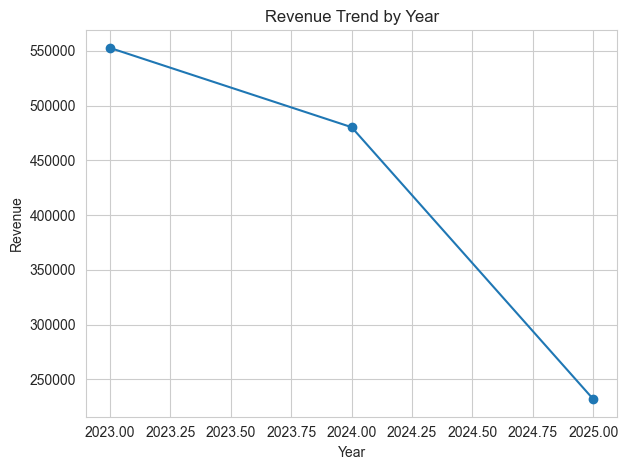

In [24]:
yearly_rev = df.groupby('Year')['Revenue'].sum()

plt.figure()
yearly_rev.plot(marker='o')
plt.title("Revenue Trend by Year")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("charts/revenue_by_year.png")
plt.show()

2. REVENUE BY MONTH

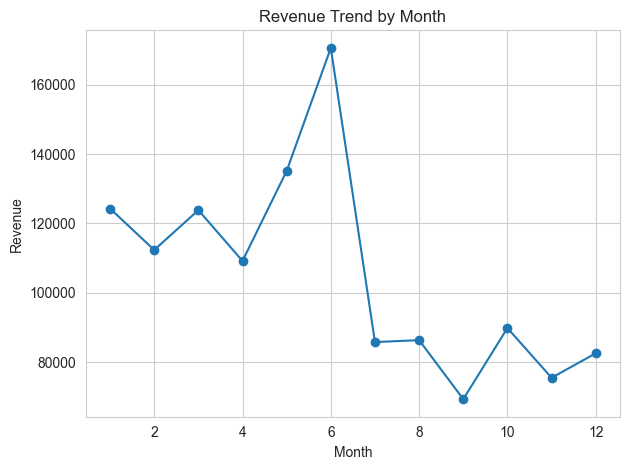

In [25]:
monthly_rev = (
    df.groupby('Month_Number')['Revenue']
    .sum()
)

plt.figure()
monthly_rev.plot(marker='o')
plt.title("Revenue Trend by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("charts/revenue_by_month.png")
plt.show()

3. REVENUE BY QUARTER

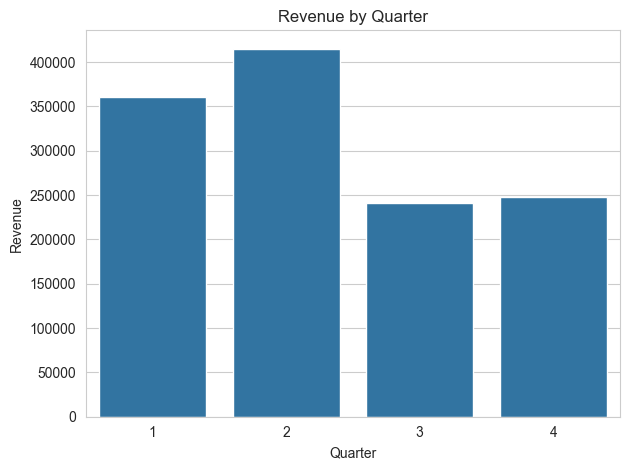

In [26]:
quarterly_rev = (
    df.groupby('Quarter')['Revenue']
    .sum()
)

plt.figure()
sns.barplot(
    x=quarterly_rev.index,
    y=quarterly_rev.values
)

plt.title("Revenue by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Revenue")

plt.tight_layout()
plt.savefig("charts/revenue_by_quarter.png")
plt.show()

4. TOP PRODUCTS BY REVENUE

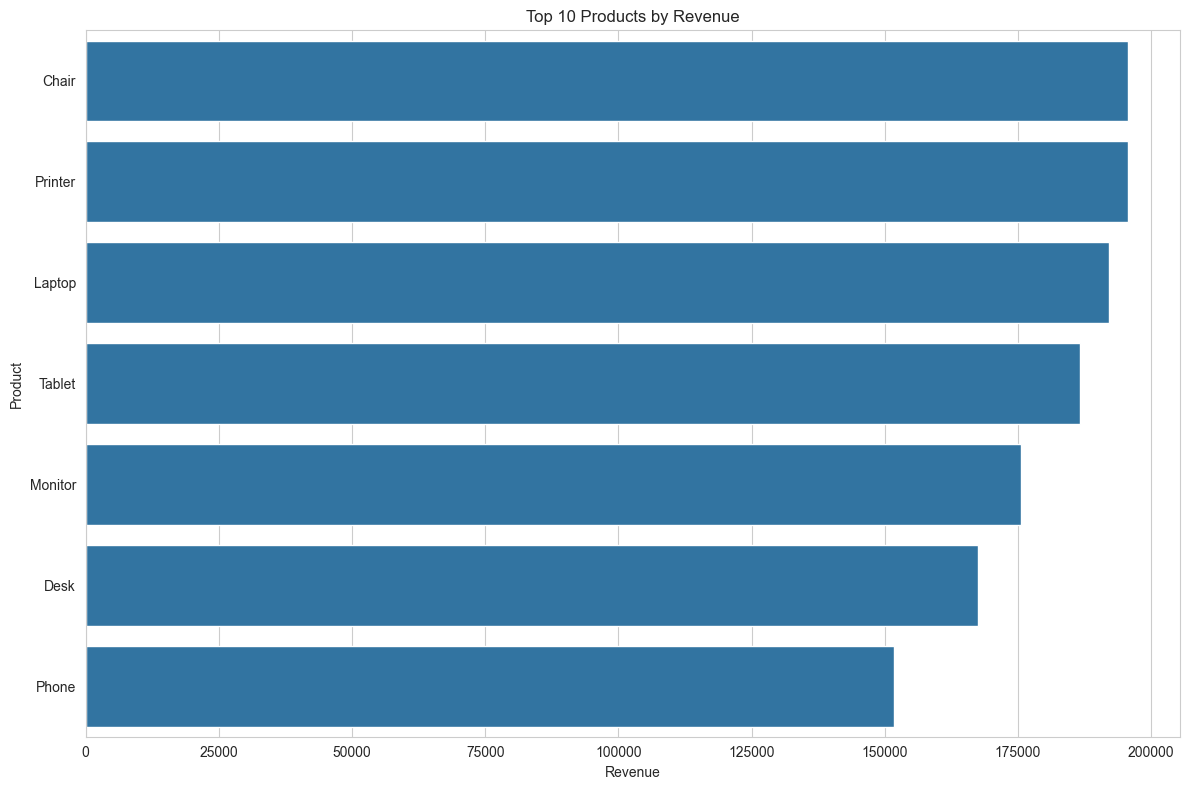

In [27]:
product_revenue = (
    df.groupby('Product')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=product_revenue.head(10).values,
    y=product_revenue.head(10).index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.savefig("charts/top_products_revenue.png")
plt.show()

5. TOP PRODUCTS BY QUANTITY

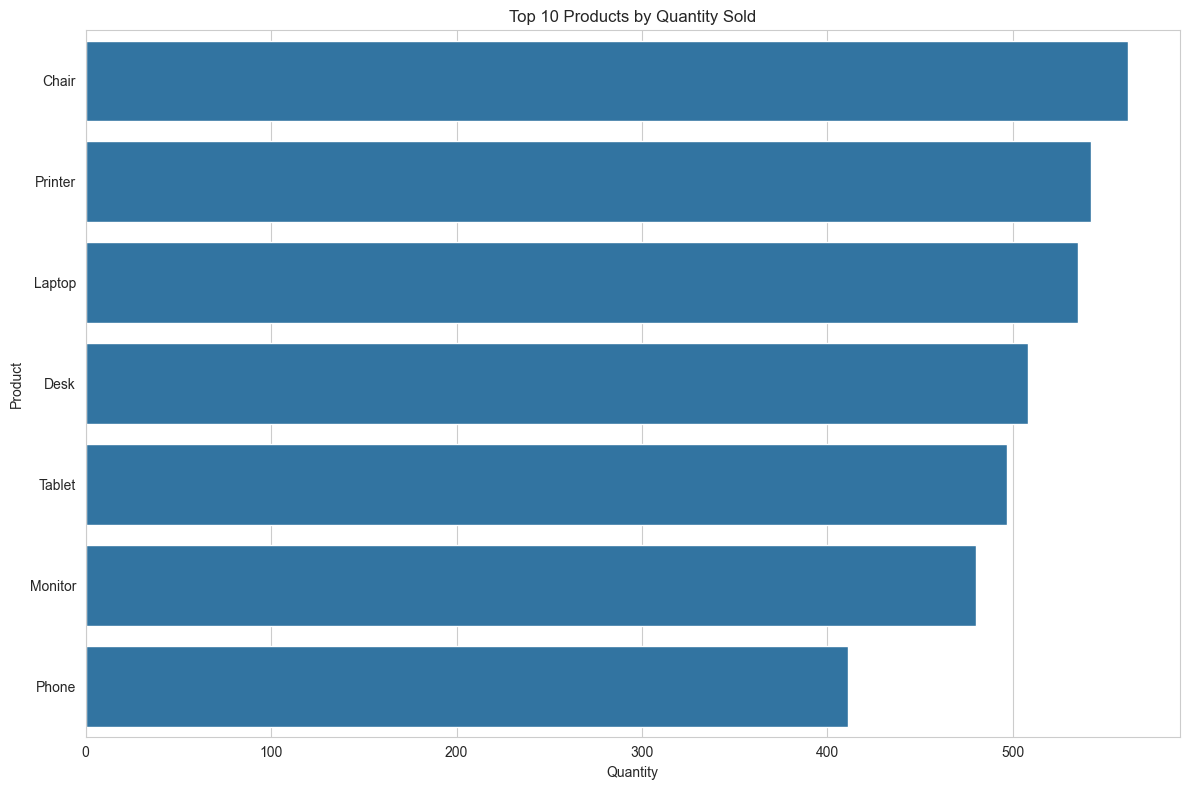

In [28]:
product_qty = (
    df.groupby('Product')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=product_qty.head(10).values,
    y=product_qty.head(10).index
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Product")

plt.tight_layout()
plt.savefig("charts/top_products_quantity.png")
plt.show()

6. ORDER STATUS ANALYSIS

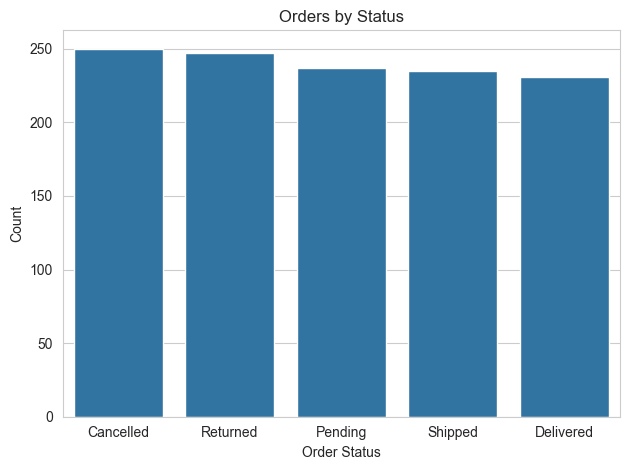


Order Status %
OrderStatus
Cancelled    20.83
Returned     20.58
Pending      19.75
Shipped      19.58
Delivered    19.25
Name: proportion, dtype: float64


In [ ]:
status_counts = df['OrderStatus'].value_counts()

plt.figure()

sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)

plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("charts/order_status.png")
plt.show()

print("\nOrder Status %")

status_percent = (
    df['OrderStatus']
    .value_counts(normalize=True)
    * 100
)

print(status_percent.round(2))

7. PAYMENT METHOD ANALYSIS

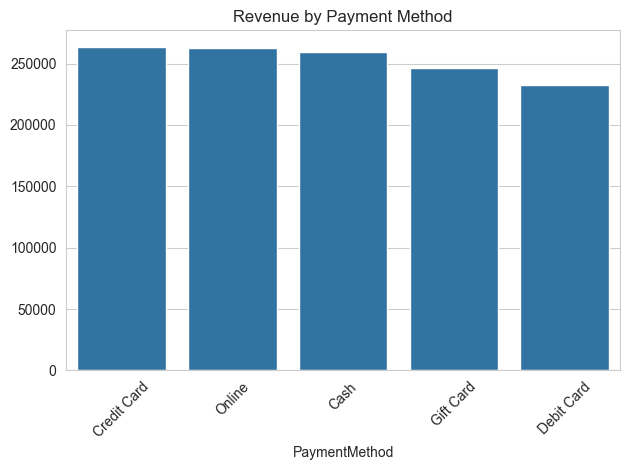

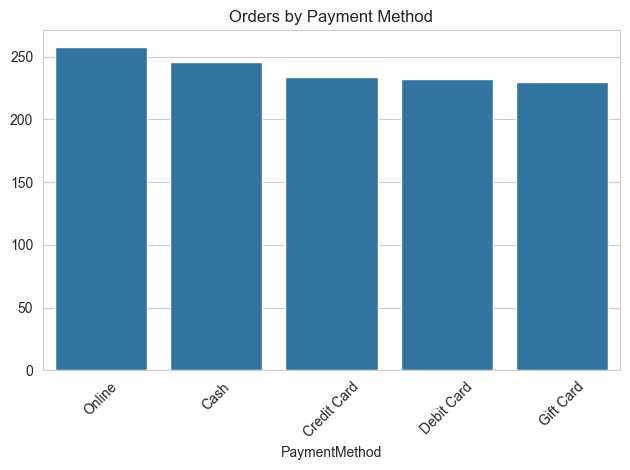

In [31]:
payment_rev = (
    df.groupby('PaymentMethod')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure()

sns.barplot(
    x=payment_rev.index,
    y=payment_rev.values
)

plt.title("Revenue by Payment Method")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/payment_revenue.png")
plt.show()

# Orders by payment method

payment_orders = df['PaymentMethod'].value_counts()

plt.figure()

sns.barplot(
    x=payment_orders.index,
    y=payment_orders.values
)

plt.title("Orders by Payment Method")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/payment_orders.png")
plt.show()

8. REFERRAL SOURCE ANALYSIS

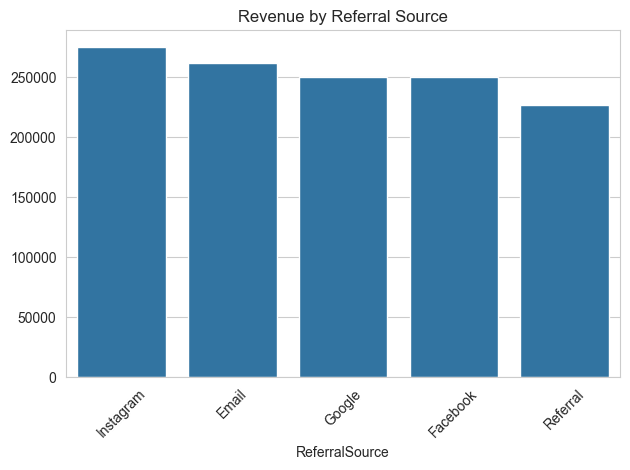

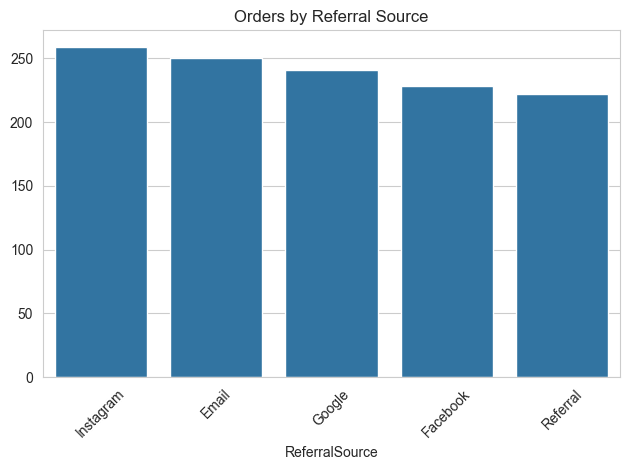

In [32]:
referral_rev = (
    df.groupby('ReferralSource')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure()

sns.barplot(
    x=referral_rev.index,
    y=referral_rev.values
)

plt.title("Revenue by Referral Source")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/referral_revenue.png")
plt.show()

referral_orders = (
    df['ReferralSource']
    .value_counts()
)

plt.figure()

sns.barplot(
    x=referral_orders.index,
    y=referral_orders.values
)

plt.title("Orders by Referral Source")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/referral_orders.png")
plt.show()

9. COUPON ANALYSIS

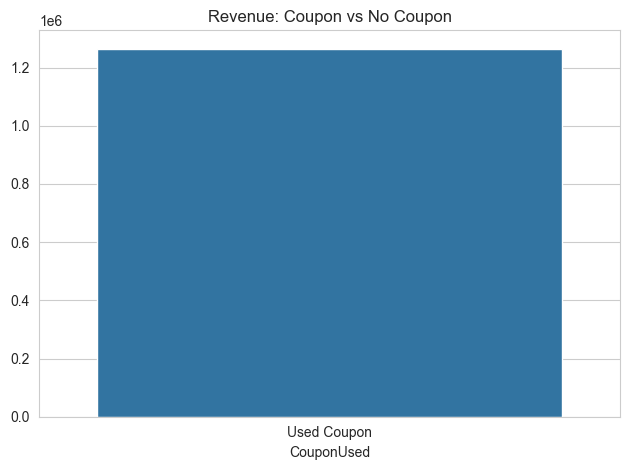

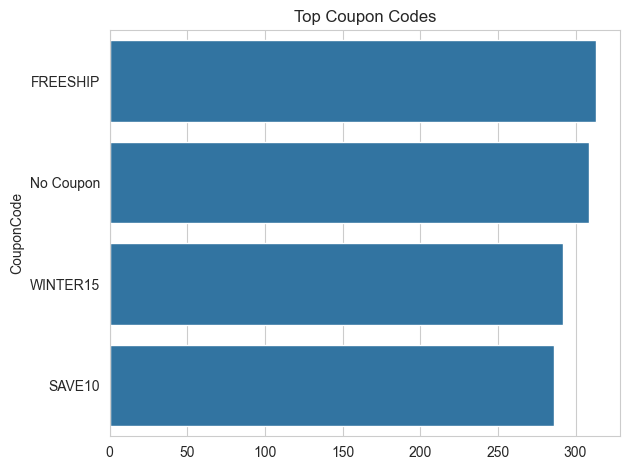

In [33]:
df['CouponUsed'] = np.where(
    df['CouponCode'].notna(),
    'Used Coupon',
    'No Coupon'
)

coupon_rev = (
    df.groupby('CouponUsed')['Revenue']
    .sum()
)

plt.figure()

sns.barplot(
    x=coupon_rev.index,
    y=coupon_rev.values
)

plt.title("Revenue: Coupon vs No Coupon")

plt.tight_layout()
plt.savefig("charts/coupon_vs_nocoupon.png")
plt.show()

# Most Used Coupon

coupon_usage = (
    df['CouponCode']
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure()

sns.barplot(
    x=coupon_usage.values,
    y=coupon_usage.index
)

plt.title("Top Coupon Codes")

plt.tight_layout()
plt.savefig("charts/top_coupons.png")
plt.show()

 10. CUSTOMER ANALYSIS

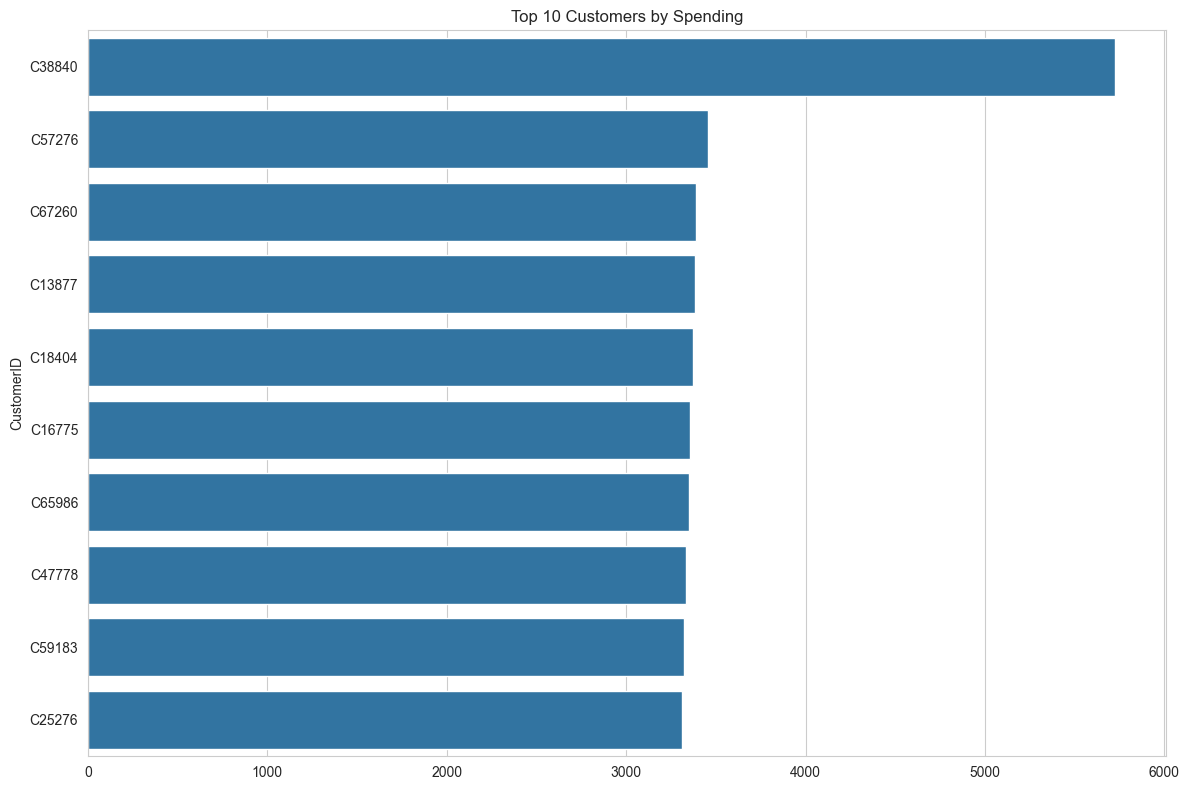

In [34]:
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Top 10 Customers by Spending")

plt.tight_layout()
plt.savefig("charts/top_customers.png")
plt.show()

INSIGHTS SUMMARY

In [35]:
print("\n========== EXECUTIVE INSIGHTS ==========")
print(
    f"\nHighest Revenue Product: "
    f"{product_revenue.idxmax()}"
)
print(
    f"Highest Revenue Payment Method: "
    f"{payment_rev.idxmax()}"
)
print(
    f"Best Referral Source: "
    f"{referral_rev.idxmax()}"
)
print(
    f"Top Customer: "
    f"{top_customers.idxmax()}"
)
print(
    f"Delivered Orders %: "
    f"{status_percent.get('Delivered',0):.2f}%"
)


========== EXECUTIVE INSIGHTS ==========

Highest Revenue Product: Chair
Highest Revenue Payment Method: Credit Card
Best Referral Source: Instagram
Top Customer: C38840
Delivered Orders %: 19.25%
